In [1]:
from sklearn.datasets import load_diabetes

In [2]:
data=load_diabetes()

In [ ]:
type(data)

sklearn.utils._bunch.Bunch

In [24]:
import pandas as pd
df=pd.DataFrame(data=data.data, columns=data.feature_names)
y=pd.Series(data.target, name='target')

In [11]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [12]:
df.shape

(442, 10)

In [15]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2, include_bias=False )

In [18]:
poly_features=['bmi', 'bp', 's5']
df_poly=df[poly_features]
expanded_features=poly.fit_transform(df_poly)

In [20]:
expanded_feature_names=poly.get_feature_names_out(poly_features)
len(expanded_feature_names)-len(poly_features)

6

In [21]:
df_poly_expanded=pd.DataFrame(expanded_features, columns=expanded_feature_names)
df_poly_expanded.head()

,bmi,bp,s5,bmi^2,bmi bp,bmi s5,bp^2,bp s5,s5^2
0,0.061696,0.021872,0.019907,0.003806,0.001349,0.001228,0.000478,0.000435,0.000396
1,-0.051474,-0.026328,-0.068332,0.002650,0.001355,0.003517,0.000693,0.001799,0.004669
2,0.044451,-0.005670,0.002861,0.001976,-0.000252,0.000127,0.000032,-0.000016,0.000008
3,-0.011595,-0.036656,0.022688,0.000134,0.000425,-0.000263,0.001344,-0.000832,0.000515
4,-0.036385,0.021872,-0.031988,0.001324,-0.000796,0.001164,0.000478,-0.000700,0.001023


In [22]:
remaining_features=df.drop(columns=poly_features)
final_df=pd.concat([remaining_features, df_poly_expanded], axis=1)

In [23]:
final_df.head()

,age,sex,s1,s2,s3,s4,s6,bmi,bp,s5,bmi^2,bmi bp,bmi s5,bp^2,bp s5,s5^2
0,0.038076,0.050680,-0.044223,-0.034821,-0.043401,-0.002592,-0.017646,0.061696,0.021872,0.019907,0.003806,0.001349,0.001228,0.000478,0.000435,0.000396
1,-0.001882,-0.044642,-0.008449,-0.019163,0.074412,-0.039493,-0.092204,-0.051474,-0.026328,-0.068332,0.002650,0.001355,0.003517,0.000693,0.001799,0.004669
2,0.085299,0.050680,-0.045599,-0.034194,-0.032356,-0.002592,-0.025930,0.044451,-0.005670,0.002861,0.001976,-0.000252,0.000127,0.000032,-0.000016,0.000008
3,-0.089063,-0.044642,0.012191,0.024991,-0.036038,0.034309,-0.009362,-0.011595,-0.036656,0.022688,0.000134,0.000425,-0.000263,0.001344,-0.000832,0.000515
4,0.005383,-0.044642,0.003935,0.015596,0.008142,-0.002592,-0.046641,-0.036385,0.021872,-0.031988,0.001324,-0.000796,0.001164,0.000478,-0.000700,0.001023


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train_base, x_test_base, y_train, y_test=train_test_split(df, y, test_size=0.2, random_state=42)
x_train_poly, x_test_poly, _, _=train_test_split(final_df, y, test_size=0.2, random_state=42)

In [27]:
lin_reg=LinearRegression()
lin_reg.fit(x_train_base, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
poly_reg=LinearRegression()
poly_reg.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
coef_df=pd.DataFrame({
    'Feature': x_train_poly.columns,
    'Coefficient': poly_reg.coef_
})
coef_df['Abs coefficients']=coef_df['Coefficient'].abs()


In [34]:
top_10=coef_df.sort_values(by='Abs coefficients', ascending=False).head(10)
top_10

,Feature,Coefficient,Abs coefficients
15,s5^2,8986.132070,8986.132070
2,s1,-4848.596988,4848.596988
3,s2,3992.388887,3992.388887
11,bmi bp,2208.766675,2208.766675
9,s5,2143.547105,2143.547105
10,bmi^2,1956.301129,1956.301129
12,bmi s5,-1786.833975,1786.833975
14,bp s5,1617.634014,1617.634014
4,s3,1616.551283,1616.551283
13,bp^2,-710.478435,710.478435


In [35]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
y_pred_base=lin_reg.predict(x_test_base)
y_pred_poly=poly_reg.predict(x_test_poly)

In [36]:
mae_base=mean_absolute_error(y_test, y_pred_base)
mae_poly=mean_absolute_error(y_test, y_pred_poly)

In [37]:
mae_base, mae_poly

(42.79409467959994, 41.81631586505526)

In [38]:
rmse_base=root_mean_squared_error(y_test, y_pred_base)
rmse_poly=root_mean_squared_error(y_test, y_pred_poly)

In [39]:
rmse_base, rmse_poly

(53.85344583676591, 52.45681773140025)

In [40]:
r2_score_base=r2_score(y_test, y_pred_base)
r2_score_poly=r2_score(y_test, y_pred_poly)

In [41]:
r2_score_base, r2_score_poly

(0.4526027629719198, 0.4806268568513944)

In [42]:
import matplotlib.pyplot as plt 


In [57]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

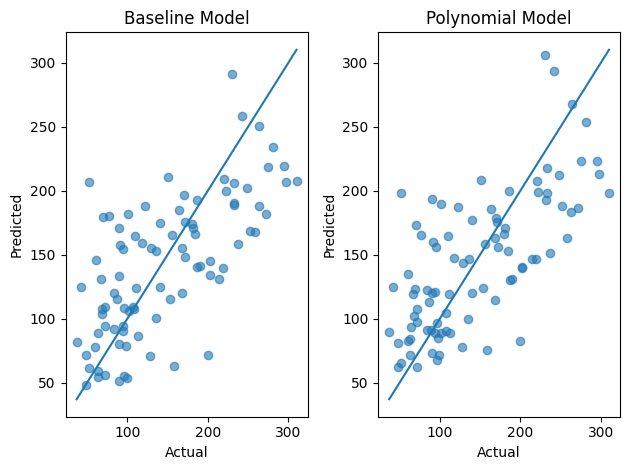

In [56]:
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_base, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Baseline Model')


plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_poly, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Polynomial Model')

plt.tight_layout()
plt.show()

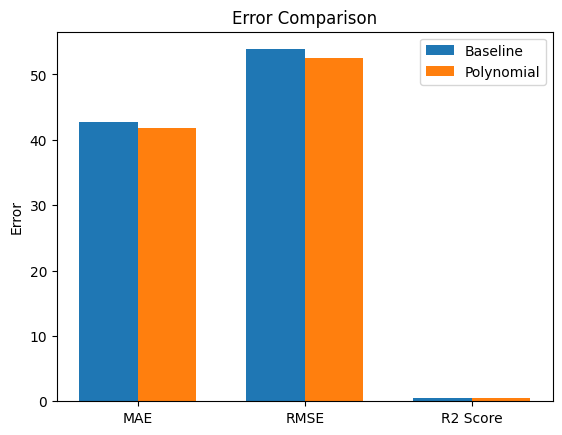

In [61]:
import numpy as np
labels=['MAE', 'RMSE', 'R2 Score']
baseline_metrics=[mae_base, rmse_base, r2_score_base]
poly_metrics=[mae_poly, rmse_poly, r2_score_poly]
x=np.arange(len(labels))
width=0.35
plt.bar(x - width/2, baseline_metrics, width, label='Baseline')
plt.bar(x + width/2, poly_metrics, width, label='Polynomial')
plt.xticks(x, labels)
plt.ylabel('Error')
plt.legend()
plt.title('Error Comparison')
plt.show()

In [63]:
sample = pd.DataFrame([{
    "age": 0.05,
    "sex": 0.02,
    "bmi": 0.04,
    "bp": 0.03,
    "s1": -0.02,
    "s2": -0.01,
    "s3": 0.00,
    "s4": 0.02,
    "s5": 0.03,
    "s6": 0.01
}])


In [65]:
baseline_prediction=lin_reg.predict(sample)
baseline_prediction

array([222.05796854])

In [66]:
sample_poly_part=sample[poly_features]
sample_poly_expanded=poly.transform(sample_poly_part)
sample_poly_expanded_df=pd.DataFrame(sample_poly_expanded, columns=expanded_feature_names)
sample_remaining=sample.drop(columns=poly_features)
sample_final=pd.concat([sample_remaining, sample_poly_expanded_df], axis=1)

In [67]:
polynomial_prediction=poly_reg.predict(sample_final)
polynomial_prediction

array([292.62759961])